In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df1 = pd.read_csv("indian_engineering_student_placement.csv")
df2 = pd.read_csv("placement_targets.csv")

df = pd.merge(df1, df2, on="Student_ID")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

In [4]:
df.shape

(5000, 25)

In [5]:
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [6]:
df.columns

Index(['Student_ID', 'gender', 'branch', 'cgpa', 'tenth_percentage',
       'twelfth_percentage', 'backlogs', 'study_hours_per_day',
       'attendance_percentage', 'projects_completed', 'internships_completed',
       'coding_skill_rating', 'communication_skill_rating',
       'aptitude_skill_rating', 'hackathons_participated',
       'certifications_count', 'sleep_hours', 'stress_level', 'part_time_job',
       'family_income_level', 'city_tier', 'internet_access',
       'extracurricular_involvement', 'placement_status', 'salary_lpa'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Student_ID,0
gender,0
branch,0
cgpa,0
tenth_percentage,0
twelfth_percentage,0
backlogs,0
study_hours_per_day,0
attendance_percentage,0
projects_completed,0


In [8]:
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna("No")

In [9]:
df.dtypes

,0
Student_ID,int64
gender,object
branch,object
cgpa,float64
tenth_percentage,float64
twelfth_percentage,float64
backlogs,int64
study_hours_per_day,float64
attendance_percentage,float64
projects_completed,int64


In [10]:
df.drop(['Student_ID', 'salary_lpa'], axis=1, inplace=True)

In [11]:
df.drop(['sleep_hours', 'internet_access'], axis=1, inplace=True)

Features & Target

In [12]:
X = df.drop('placement_status', axis=1)
y = df['placement_status']

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'gender', 'branch', 'part_time_job',
    'family_income_level', 'city_tier',
     'extracurricular_involvement'
]

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

In [26]:
df.dtypes

,0
gender,object
branch,object
cgpa,float64
tenth_percentage,float64
twelfth_percentage,float64
backlogs,int64
study_hours_per_day,float64
attendance_percentage,float64
projects_completed,int64
internships_completed,int64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Report:", classification_report(y_test, y_pred))

Accuracy: 0.894
Confusion Matrix: [[ 69  69]
 [ 37 825]]
Report:               precision    recall  f1-score   support

  Not Placed       0.65      0.50      0.57       138
      Placed       0.92      0.96      0.94       862

    accuracy                           0.89      1000
   macro avg       0.79      0.73      0.75      1000
weighted avg       0.89      0.89      0.89      1000



In [19]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

print(importance.sort_values(by='Importance', ascending=False))

                        Feature  Importance
10          coding_skill_rating    0.688300
2                          cgpa    0.594625
9         internships_completed    0.548863
11   communication_skill_rating    0.391386
8            projects_completed    0.382941
12        aptitude_skill_rating    0.098814
19  extracurricular_involvement    0.076035
14         certifications_count    0.061403
13      hackathons_participated    0.052452
16                part_time_job    0.010614
1                        branch    0.006075
0                        gender    0.000838
6           study_hours_per_day   -0.002349
18                    city_tier   -0.005655
17          family_income_level   -0.018059
15                 stress_level   -0.021136
4            twelfth_percentage   -0.062767
7         attendance_percentage   -0.122137
3              tenth_percentage   -0.199321
5                      backlogs   -0.988184


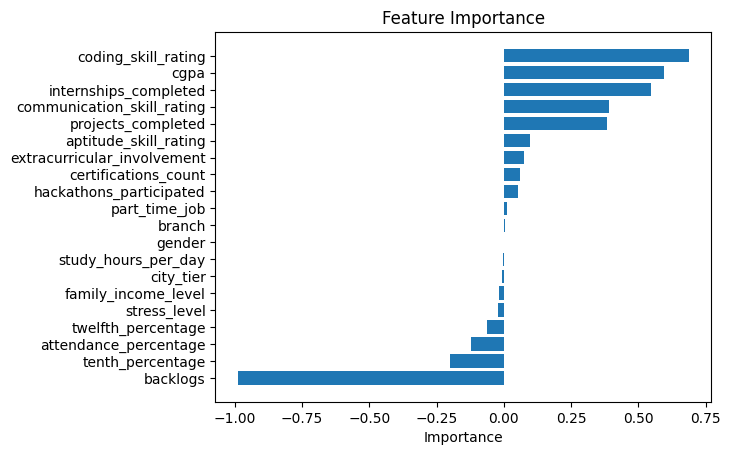

In [20]:
import matplotlib.pyplot as plt

importance = importance.sort_values(by='Importance', ascending=False)

plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [21]:
from sklearn.cluster import KMeans

X_cluster = df[['cgpa', 'internships_completed', 'coding_skill_rating']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

High performers = Green , Average students = Blue , Low performers = Red

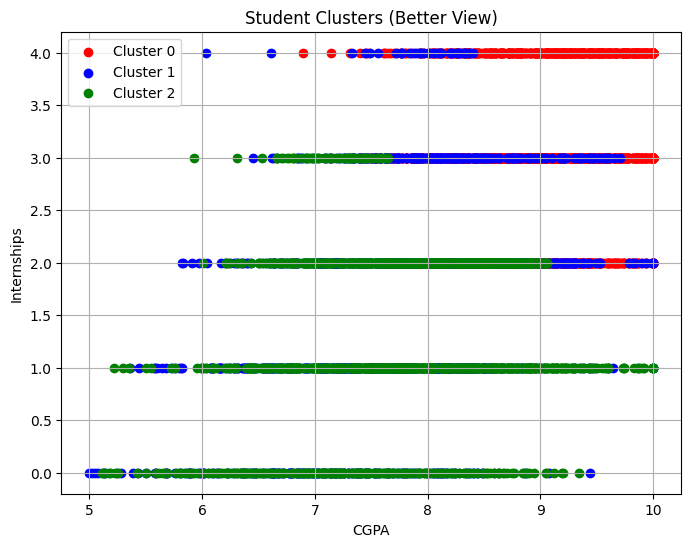

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for i in range(3):
    plt.scatter(
        df['cgpa'][kmeans.labels_ == i],
        df['internships_completed'][kmeans.labels_ == i],
        c=colors[i],
        label=f'Cluster {i}'
    )

plt.xlabel("CGPA")
plt.ylabel("Internships")
plt.title("Student Clusters (Better View)")
plt.legend()
plt.grid()

plt.show()

In [23]:
df['risk_level'] = df['placement_status'].map({
    1: "Low Risk",
    0: "High Risk"
})

In [24]:
df['readiness_level'] = (
    df['cgpa'] +
    df['internships_completed'] +
    df['coding_skill_rating']
)

df['readiness_level'] = df['readiness_level'].apply(
    lambda x: "High" if x >= 12 else ("Medium" if x >= 8 else "Low")
)

In [27]:
def student_analysis(pred, readiness, risk):

    # ===== Placement Message =====
    if pred == 1:
        placement = "Placed (High Probability)"
    else:
        placement = "Not Placed (Low Probability)"

    # ===== Readiness Message =====
    if readiness == "High":
        readiness_msg = "You are well prepared for placements."
        motivation = "Great job! Keep improving and stay consistent."
    elif readiness == "Medium":
        readiness_msg = "You are moderately prepared but need improvement."
        motivation = "Focus on skills and practice more — you can do it!"
    else:
        readiness_msg = "You are not ready yet for placements."
        motivation = "Start working on your skills — improvement is possible!"

    # ===== Risk Message =====
    if risk == "Low Risk":
        risk_msg = "Your risk is low. You have good chances of placement."
    else:
        risk_msg = "Your risk is high. You need to improve your profile."

    # ===== Final Output =====
    return f"""
Placement Prediction: {placement}

Readiness Level: {readiness}
Risk Level: {risk}

Analysis:
{readiness_msg}
{risk_msg}

Motivation:
{motivation}
"""

In [32]:
import joblib

joblib.dump(model, "placement__model.pkl")

['placement__model.pkl']

In [33]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']